# Symbolic comparison of the two implicit ABBA Jacobian factorizations

This notebook uses exact SymPy matrix algebra to compare

$$J_n^{\mathrm{IFT}}=P-QK^{-1}L$$

with

$$J_n^{\mathrm{inc}}=I+\frac{h}{4}(Dk_1+Dk_2+Dk_3+Dk_4).$$

The stage matrices $W_i=Df_i$ are noncommuting $2\times2$ matrix symbols. No commutativity, finite-difference approximation, or floating-point simplification is used.

In [ ]:
import sympy as sp
from IPython.display import display

sp.init_printing()
print(f"SymPy version: {sp.__version__}")

SymPy version: 1.14.0


## 1. Noncommuting stage symbols

Let $s=h/2$. The matrices $W_1,\ldots,W_4$ are the spatial Jacobians of the vector field evaluated at the four converged ABBA stage points. The symbol $M$ denotes the still-unspecified total derivative $D\mu_h(z_n)$.

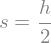

In [ ]:
h = sp.symbols("h", nonzero=True, real=True)
s = h / 2
I2 = sp.Identity(2)
Z2 = sp.ZeroMatrix(2, 2)
W1, W2, W3, W4 = (
    sp.MatrixSymbol(f"W_{index}", 2, 2) for index in range(1, 5)
)
M = sp.MatrixSymbol("M", 2, 2)
S = W2 + W3

assert all(matrix.shape == (2, 2) for matrix in (W1, W2, W3, W4, M))
display(sp.Eq(sp.Symbol("s"), h / 2, evaluate=False))
display(sp.Eq(sp.MatrixSymbol("S", 2, 2), S, evaluate=False))

## 2. ABBA block Jacobian and implicit-function matrices

The differentiated four-stage duplicated map is written as

$$D\Phi^{\mathrm{ABBA}}=\begin{pmatrix}A&B\\C&D\end{pmatrix}.$$

From these blocks, $K=D_\mu R$ and $L=D_zR$ differentiate the projection residual, while $P$ and $Q$ differentiate the corrected first copy.

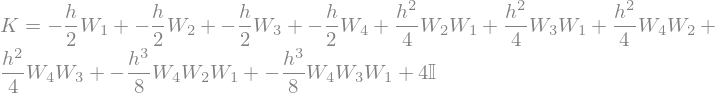

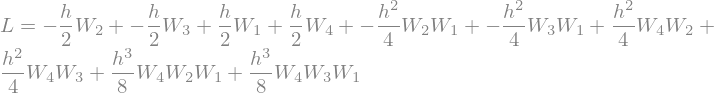

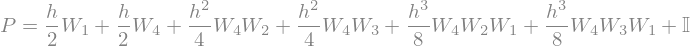

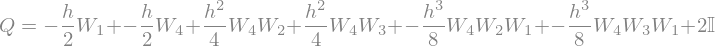

In [ ]:
A = I2 + s**2 * W4 * S
B = s * (W1 + W4) + s**3 * W4 * S * W1
C = s * S
D = I2 + s**2 * S * W1

K = A - B - C + D + 2 * I2
L = A + B - C - D
P = A + B
Q = A - B + I2

for name, expression in (("K", K), ("L", L), ("P", P), ("Q", Q)):
    display(
        sp.Eq(
            sp.MatrixSymbol(name, 2, 2),
            sp.expand(expression),
            evaluate=False,
        )
    )

## 3. Implicit-function factorization

At an exact projection root, differentiating $R(z,\mu_h(z))=0$ gives

$$L+KM=0,\qquad M=D\mu_h(z_n)=-K^{-1}L.$$

The corrected-first-copy derivative is $P+QM$. Substitution of the implicit derivative produces the first requested expression.

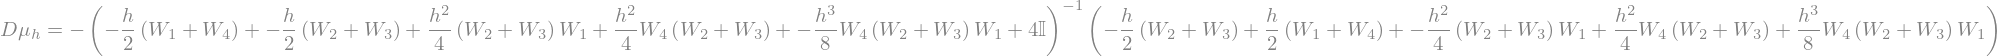

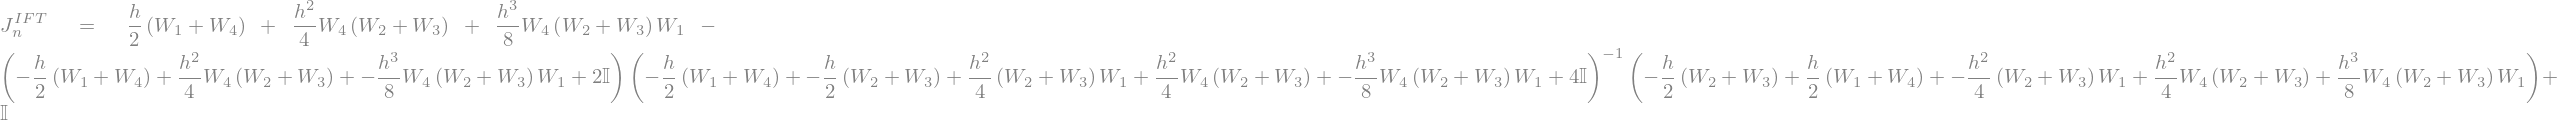

In [ ]:
M_root = -sp.Inverse(K) * L
J_copy = P + Q * M
J_ift = P - Q * sp.Inverse(K) * L

assert sp.simplify(J_copy.xreplace({M: M_root}) - J_ift) == Z2
display(
    sp.Eq(
        sp.MatrixSymbol(r"D\mu_h", 2, 2),
        M_root,
        evaluate=False,
    )
)
display(
    sp.Eq(
        sp.MatrixSymbol(r"J_n^{IFT}", 2, 2),
        J_ift,
        evaluate=False,
    )
)

## 4. Stage-increment factorization

The mean of the two corrected copies can be written as

$$z_{n+1}=z_n+\frac{h}{4}(k_1+k_2+k_3+k_4).$$

The $Dk_i$ below are total derivatives. In particular, they include $M=D\mu_h(z_n)$; treating $M$ as zero would differentiate a different map.

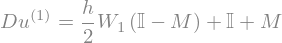

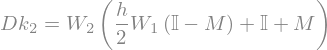

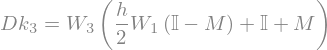

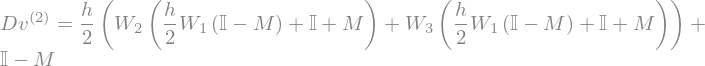

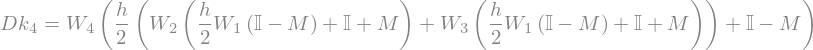

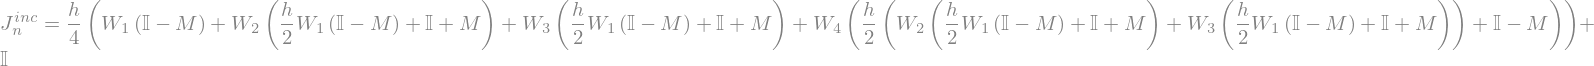

In [ ]:
Dk1 = W1 * (I2 - M)
Du1 = I2 + M + s * Dk1
Dk2 = W2 * Du1
Dk3 = W3 * Du1
Dv2 = I2 - M + s * (Dk2 + Dk3)
Dk4 = W4 * Dv2
J_increment = I2 + h / 4 * (Dk1 + Dk2 + Dk3 + Dk4)

for name, expression in (
    (r"Dk_1", Dk1),
    (r"Du^{(1)}", Du1),
    (r"Dk_2", Dk2),
    (r"Dk_3", Dk3),
    (r"Dv^{(2)}", Dv2),
    (r"Dk_4", Dk4),
):
    display(
        sp.Eq(sp.MatrixSymbol(name, 2, 2), expression, evaluate=False)
    )
display(
    sp.Eq(
        sp.MatrixSymbol(r"J_n^{inc}", 2, 2),
        J_increment,
        evaluate=False,
    )
)

## 5. Symbolic comparison before imposing the root equation

The increment derivative is the derivative of the mean of both corrected copies, whereas $P+QM$ differentiates the corrected first copy. SymPy proves that their difference is exactly one half of the total residual derivative, with the appropriate sign:

$$J_n^{\mathrm{inc}}-(P+QM)=-\frac12(L+KM).$$

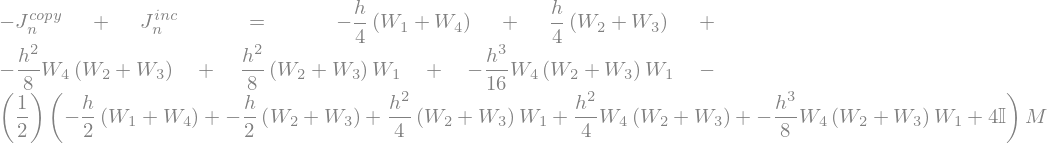

Verified without commutativity assumptions: remainder = 0


In [ ]:
difference_remainder = sp.expand(
    J_increment - J_copy + sp.Rational(1, 2) * (L + K * M)
)
assert difference_remainder == Z2

display(
    sp.Eq(
        sp.MatrixSymbol(r"J_n^{inc}", 2, 2)
        - sp.MatrixSymbol(r"J_n^{copy}", 2, 2),
        -sp.Rational(1, 2) * (L + K * M),
        evaluate=False,
    )
)
print("Verified without commutativity assumptions: remainder =", difference_remainder)

## 6. Equality at the implicit root

Substituting $M=-K^{-1}L$ makes the total residual derivative vanish. Combining this with the identity above proves that the two requested Jacobians are symbolically identical at the root.

In [ ]:
residual_derivative_at_root = sp.simplify(L + K * M_root)
copy_difference_at_root = sp.simplify(
    J_copy.xreplace({M: M_root}) - J_ift
)
increment_difference_at_root = (
    -sp.Rational(1, 2) * residual_derivative_at_root
)

assert residual_derivative_at_root == Z2
assert copy_difference_at_root == Z2
assert increment_difference_at_root == Z2

display(
    sp.Eq(
        sp.MatrixSymbol("L", 2, 2)
        + sp.MatrixSymbol("K", 2, 2)
        * sp.MatrixSymbol(r"D\mu_h", 2, 2),
        Z2,
        evaluate=False,
    )
)
display(
    sp.Eq(
        sp.MatrixSymbol(r"J_n^{inc}", 2, 2),
        sp.MatrixSymbol(r"J_n^{IFT}", 2, 2),
        evaluate=False,
    )
)
print("Residual derivative after substitution:", residual_derivative_at_root)
print("Exact symbolic difference at the root:", increment_difference_at_root)

Residual derivative after substitution: 0
Exact symbolic difference at the root: 0


## 7. Exact noncommuting rational example

A final substitution uses four different guiding-center Jacobians with rational entries. Their products do not commute. Both constructions nevertheless return exactly the same rational matrix, which is symplectic and has determinant one.

Nonzero commutator [W4, W2 + W3]:


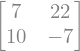

Jacobian from the implicit-function factorization:


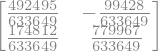

Jacobian from the stage-increment factorization:


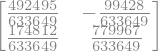

Exact difference:


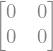

det(J_n) = 1


In [ ]:
J0 = sp.Matrix([[0, -1], [1, 0]])

def gc_jacobian(phi_xx, phi_xy, phi_yy):
    """Return the exact GC matrix J0 Hess(phi)."""
    return sp.Matrix([[-phi_xy, -phi_yy], [phi_xx, phi_xy]])


W1_e = gc_jacobian(2, 1, 3)
W2_e = gc_jacobian(-1, 2, 1)
W3_e = gc_jacobian(3, -1, 2)
W4_e = gc_jacobian(1, 3, -2)
h_e = sp.Rational(1, 5)
s_e = h_e / 2
I_e = sp.eye(2)
S_e = W2_e + W3_e

assert W4_e * S_e != S_e * W4_e
assert all(
    W.T * J0 + J0 * W == sp.zeros(2)
    for W in (W1_e, W2_e, W3_e, W4_e)
)

A_e = I_e + s_e**2 * W4_e * S_e
B_e = s_e * (W1_e + W4_e) + s_e**3 * W4_e * S_e * W1_e
C_e = s_e * S_e
D_e = I_e + s_e**2 * S_e * W1_e
K_e = A_e - B_e - C_e + D_e + 2 * I_e
L_e = A_e + B_e - C_e - D_e
P_e = A_e + B_e
Q_e = A_e - B_e + I_e
M_e = -K_e.inv() * L_e
J_ift_e = sp.simplify(P_e + Q_e * M_e)

Dk1_e = W1_e * (I_e - M_e)
Du1_e = I_e + M_e + s_e * Dk1_e
Dk2_e = W2_e * Du1_e
Dk3_e = W3_e * Du1_e
Dv2_e = I_e - M_e + s_e * (Dk2_e + Dk3_e)
Dk4_e = W4_e * Dv2_e
J_increment_e = sp.simplify(
    I_e + h_e / 4 * (Dk1_e + Dk2_e + Dk3_e + Dk4_e)
)
exact_difference = sp.simplify(J_increment_e - J_ift_e)

assert K_e.det() != 0
assert exact_difference == sp.zeros(2)
assert sp.factor(J_ift_e.det()) == 1
assert sp.simplify(J_ift_e.T * J0 * J_ift_e - J0) == sp.zeros(2)

print("Nonzero commutator [W4, W2 + W3]:")
display(W4_e * S_e - S_e * W4_e)
print("Jacobian from the implicit-function factorization:")
display(J_ift_e)
print("Jacobian from the stage-increment factorization:")
display(J_increment_e)
print("Exact difference:")
display(exact_difference)
print(f"det(J_n) = {sp.factor(J_ift_e.det())}")

## Conclusions

- The two formulas are initially different symbolic constructions.
- Before imposing the implicit-root derivative, their difference is exactly $-\tfrac12(L+KM)$.
- The implicit function theorem gives $M=-K^{-1}L$, so $L+KM=0$.
- Therefore $J_n^{\mathrm{inc}}=J_n^{\mathrm{IFT}}$ exactly, without assuming that the $W_i$ commute.
- They remain different computational factorizations, so floating-point implementations can differ at round-off level.